In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
leads= pd.read_csv('Analisis GAC Full7agosto 2026(Leads Reales).csv') 

In [3]:
#Verificamos información del DataFrame
leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Efectivadad de Leads   4 non-null      str    
 1   Unnamed: 1             34 non-null     str    
 2   Unnamed: 2             33 non-null     str    
 3   Unnamed: 3             34 non-null     str    
 4   Unnamed: 4             33 non-null     str    
 5   Unnamed: 5             33 non-null     str    
 6   Unnamed: 6             35 non-null     str    
 7   Unnamed: 7             32 non-null     str    
 8   Unnamed: 8             34 non-null     str    
 9   Unnamed: 9             32 non-null     str    
 10  Unnamed: 10            36 non-null     str    
 11  Unnamed: 11            32 non-null     str    
 12  Unnamed: 12            2 non-null      float64
 13  Unnamed: 13            0 non-null      float64
dtypes: float64(2), str(12)
memory usage: 5.2 KB


In [4]:
#Imprimo los primeros 5 registro del dataframe
leads.head()

,Efectivadad de Leads,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,"30,189","3,851","5,748",510,929,"17,748","6,545",720,4.0%,64.0%,NaN,NaN
1,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,NaN,NaN
2,2024,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
4,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN


In [5]:
#Se observa que la base de datos es algo difícil de trabajar en como esta en el momento debido a como están organizados los datos, por lo que se hará una previa limpieza para facilitar el proceso de análisis

# Cargo la base usando la fila correcta como encabezado
leads = pd.read_csv(
    "Analisis GAC Full7agosto 2026(Leads Reales).csv",
    header=2
)

leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [6]:
# Elimino columnas completamente vacías
leads = leads.dropna(axis=1, how="all")

leads.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion ',
       'Efectividad de Leads', 'Unnamed: 12'],
      dtype='str')

In [7]:
# Defino los meses válidos
meses_validos = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

# Conservo únicamente los registros mensuales
leads = leads[
    leads["Mes"].isin(meses_validos)
].copy()

leads

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN
5,NaN,Junio,967,140,173,31,3,620,17,6,1.0%,64%,NaN
6,NaN,Julio,954,112,251,12,9,570,5,21,3.7%,60%,NaN
7,NaN,Agosto,"1,409",504,324,17,18,546,22,17,3.1%,39%,NaN
8,NaN,Septiembre,"1,315",431,314,14,26,530,42,17,3.2%,40%,NaN
9,NaN,Octubre,"1,973",514,606,18,13,822,72,23,2.8%,42%,NaN


In [8]:
# Completo el año hacia abajo
leads["Año"] = leads["Año"].ffill()

leads[["Año", "Mes"]].head(15)

,Año,Mes
0,2024.0,Enero
1,2024.0,Febrero
2,2024.0,Marzo
3,2024.0,Abril
4,2024.0,Mayo
5,2024.0,Junio
6,2024.0,Julio
7,2024.0,Agosto
8,2024.0,Septiembre
9,2024.0,Octubre


In [9]:
variables_numericas = [
    "Total",
    "Ilocalizable",
    "No Contesta",
    "D. Incorrectos",
    "Duplicados",
    "Efectivos",
    "Abiertos",
    "Ventas"
]

for variable in variables_numericas:

    leads[variable] = (
        leads[variable]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    leads[variable] = pd.to_numeric(
        leads[variable],
        errors="coerce"
    )

In [11]:
variables_porcentaje = [
    "Conversion ",
    "Efectividad de Leads"
]

for variable in variables_porcentaje:

    leads[variable] = (
        leads[variable]
        .astype(str)
        .str.replace("%", "", regex=False)
    )

    leads[variable] = pd.to_numeric(
        leads[variable],
        errors="coerce"
    )

In [12]:
leads.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 0 to 25
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   19 non-null     float64
 1   Mes                   19 non-null     str    
 2   Total                 18 non-null     float64
 3   Ilocalizable          18 non-null     float64
 4   No Contesta           18 non-null     float64
 5   D. Incorrectos        18 non-null     float64
 6   Duplicados            18 non-null     float64
 7   Efectivos             18 non-null     float64
 8   Abiertos              18 non-null     float64
 9   Ventas                18 non-null     float64
 10  Conversion            18 non-null     float64
 11  Efectividad de Leads  18 non-null     float64
 12  Unnamed: 12           0 non-null      float64
dtypes: float64(12), str(1)
memory usage: 2.1 KB


”Total”

In [13]:
# Corroboramos valores nulos
leads["Total"].isnull().sum()

np.int64(1)

In [14]:
# Calculamos el número total de la población "n"
leads["Total"].info()

n = leads["Total"].count()

n

<class 'pandas.Series'>
Index: 19 entries, 0 to 25
Series name: Total
Non-Null Count  Dtype  
--------------  -----  
18 non-null     float64
dtypes: float64(1)
memory usage: 304.0 bytes


np.int64(18)

In [15]:
# Obtenemos el límite superior y el límite inferior
Max = leads["Total"].max()
Min = leads["Total"].min()

Limites = [Min, Max]

Limites

[np.float64(178.0), np.float64(1973.0)]

In [16]:
# Calculamos el rango R

R = Max - Min

R

np.float64(1795.0)

In [17]:
# Calculamos el número de intervalos aplicando
# la regla de Sturges

ni = 1 + 3.32 * np.log10(n)

ni

np.float64(5.167504716942976)

In [18]:
# Redondeamos el número de intervalos

ni = int(np.ceil(ni))

ni

6

In [19]:
# Calculamos el ancho del intervalo

i = R / ni

i

np.float64(299.1666666666667)

In [20]:
# Creamos los intervalos

intervalos = np.linspace(
    Min - 0.001,
    Max + 0.001,
    ni + 1
)

intervalos

array([ 177.999,  477.166,  776.333, 1075.5  , 1374.667, 1673.834,
       1973.001])

In [21]:
# Creamos las categorías

categorias = []

for x in range(ni):

    categorias.append(
        f"Categoría {x+1} "
        f"({intervalos[x]:.2f}-{intervalos[x+1]:.2f})"
    )

categorias

['Categoría 1 (178.00-477.17)',
 'Categoría 2 (477.17-776.33)',
 'Categoría 3 (776.33-1075.50)',
 'Categoría 4 (1075.50-1374.67)',
 'Categoría 5 (1374.67-1673.83)',
 'Categoría 6 (1673.83-1973.00)']

In [22]:
# Creamos la nueva variable categórica

leads["Total_Categoria"] = pd.cut(
    x=leads["Total"],
    bins=intervalos,
    labels=categorias
)

leads["Total_Categoria"]

0                               NaN
1       Categoría 2 (477.17-776.33)
2       Categoría 1 (178.00-477.17)
3       Categoría 1 (178.00-477.17)
4       Categoría 1 (178.00-477.17)
5      Categoría 3 (776.33-1075.50)
6      Categoría 3 (776.33-1075.50)
7     Categoría 5 (1374.67-1673.83)
8     Categoría 4 (1075.50-1374.67)
9     Categoría 6 (1673.83-1973.00)
10    Categoría 5 (1374.67-1673.83)
11    Categoría 4 (1075.50-1374.67)
13      Categoría 2 (477.17-776.33)
17    Categoría 4 (1075.50-1374.67)
19    Categoría 5 (1374.67-1673.83)
20    Categoría 4 (1075.50-1374.67)
22     Categoría 3 (776.33-1075.50)
23    Categoría 5 (1374.67-1673.83)
25    Categoría 4 (1075.50-1374.67)
Name: Total_Categoria, dtype: category
Categories (6, str): ['Categoría 1 (178.00-477.17)' < 'Categoría 2 (477.17-776.33)' < 'Categoría 3 (776.33-1075.50)' < 'Categoría 4 (1075.50-1374.67)' < 'Categoría 5 (1374.67-1673.83)' < 'Categoría 6 (1673.83-1973.00)']

In [23]:
# Obtengo un análisis univariado

Tabla_freq = (
    leads["Total_Categoria"]
    .value_counts()
    .sort_index()
    .reset_index()
)

Tabla_freq

,Total_Categoria,count
0,Categoría 1 (178.00-477.17),3
1,Categoría 2 (477.17-776.33),2
2,Categoría 3 (776.33-1075.50),3
3,Categoría 4 (1075.50-1374.67),5
4,Categoría 5 (1374.67-1673.83),4
5,Categoría 6 (1673.83-1973.00),1


In [25]:
# Filtro categorías con frecuencia mayor a cero

Filtro = Tabla_freq[
    Tabla_freq["count"] > 1

]

Filtro

,Total_Categoria,count
0,Categoría 1 (178.00-477.17),3
1,Categoría 2 (477.17-776.33),2
2,Categoría 3 (776.33-1075.50),3
3,Categoría 4 (1075.50-1374.67),5
4,Categoría 5 (1374.67-1673.83),4


In [26]:
# Ajusto el índice

Filtro_index = Filtro.set_index(
    "Total_Categoria"
)

Filtro_index

,count
Total_Categoria,
Categoría 1 (178.00-477.17),3
Categoría 2 (477.17-776.33),2
Categoría 3 (776.33-1075.50),3
Categoría 4 (1075.50-1374.67),5
Categoría 5 (1374.67-1673.83),4


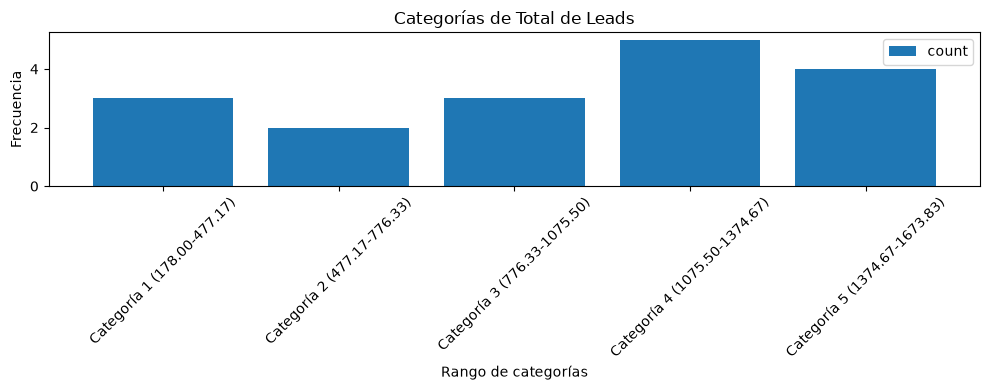

In [27]:
# Realizamos gráfico de barras

Filtro_index.plot(
    kind="bar",
    width=0.8,
    figsize=(10, 4),
    rot=45
)

plt.title("Categorías de Total de Leads")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

El mismo proceso se automatiza para las nueve restantes variables mediante una función

In [28]:
def categorizar_sturges(df, variable):

    # Elimino valores nulos de la variable
    datos = df[variable].dropna().copy()

    # Calculo el número total de observaciones
    n = len(datos)

    # Obtengo límite superior e inferior
    Max = datos.max()
    Min = datos.min()

    print("Variable:", variable)
    print("n =", n)
    print("Mínimo =", Min)
    print("Máximo =", Max)

    # Calculo el rango
    R = Max - Min
    print("Rango =", R)

    # Regla de Sturges
    ni = 1 + 3.32 * np.log10(n)

    print("Número de intervalos según Sturges =", ni)

    # Redondeamos hacia arriba para trabajar con intervalos completos
    ni_redondeado = int(np.ceil(ni))

    print("Número de intervalos utilizado =", ni_redondeado)

    # Calculo el ancho del intervalo
    i = R / ni_redondeado

    print("Ancho del intervalo =", i)

    # Creo los límites de los intervalos
    intervalos = np.linspace(
        Min,
        Max,
        ni_redondeado + 1
    )

    # Ajusto ligeramente los extremos para incluir mínimo y máximo
    intervalos[0] = intervalos[0] - 0.001
    intervalos[-1] = intervalos[-1] + 0.001

    print("Intervalos:")
    print(intervalos)

    # Creo nombres automáticos para las categorías
    categorias = []

    for x in range(ni_redondeado):

        categorias.append(
            f"Categoría {x+1} "
            f"({intervalos[x]:.2f} - {intervalos[x+1]:.2f})"
        )

    # Creo una nueva columna categorizada
    nombre_columna = variable + "_Categoria"

    df[nombre_columna] = pd.cut(
        x=df[variable],
        bins=intervalos,
        labels=categorias
    )

    # Tabla de frecuencias
    Tabla_freq = (
        df[nombre_columna]
        .value_counts()
        .sort_index()
        .reset_index()
    )

    # Filtro las categorías con observaciones
    Filtro = Tabla_freq[
        Tabla_freq["count"] > 1
    ]

    # Ajusto el índice
    Filtro_index = Filtro.set_index(
        nombre_columna
    )

    # Gráfico de barras
    Filtro_index.plot(
        kind="bar",
        width=0.8,
        figsize=(10, 4),
        rot=45
    )

    plt.title(
        "Frecuencia de categorías - " + variable
    )

    plt.xlabel(
        "Rangos de " + variable
    )

    plt.ylabel(
        "Frecuencia"
    )

    plt.tight_layout()
    plt.show()

    return Tabla_freq

“Ilocalizable”

Variable: Ilocalizable
n = 18
Mínimo = 9.0
Máximo = 514.0
Rango = 505.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 84.16666666666667
Intervalos:
[  8.999       93.16666667 177.33333333 261.5        345.66666667
 429.83333333 514.001     ]


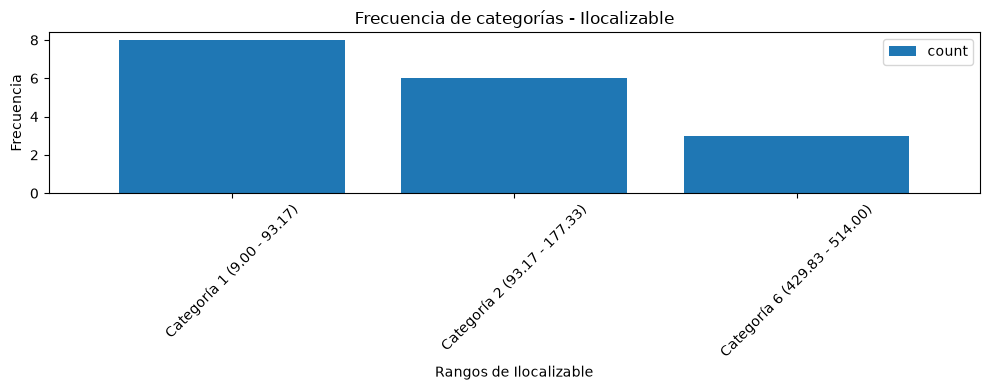

In [29]:
Tabla_Ilocalizable = categorizar_sturges(
    leads,
    "Ilocalizable"
)

“No Contesta”

Variable: No Contesta
n = 18
Mínimo = 13.0
Máximo = 606.0
Rango = 593.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 98.83333333333333
Intervalos:
[ 12.999      111.83333333 210.66666667 309.5        408.33333333
 507.16666667 606.001     ]


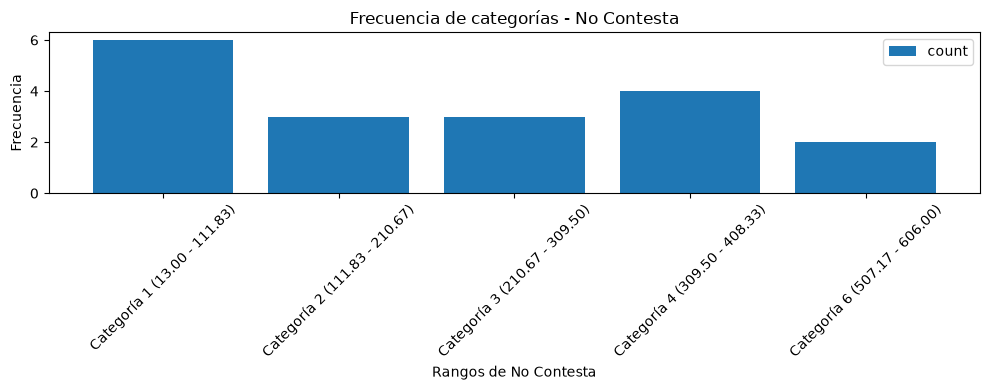

In [30]:
Tabla_NoContesta = categorizar_sturges(
    leads,
    "No Contesta"
)

“D. Incorrectos”

Variable: D. Incorrectos
n = 18
Mínimo = 0.0
Máximo = 60.0
Rango = 60.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 10.0
Intervalos:
[-1.0000e-03  1.0000e+01  2.0000e+01  3.0000e+01  4.0000e+01  5.0000e+01
  6.0001e+01]


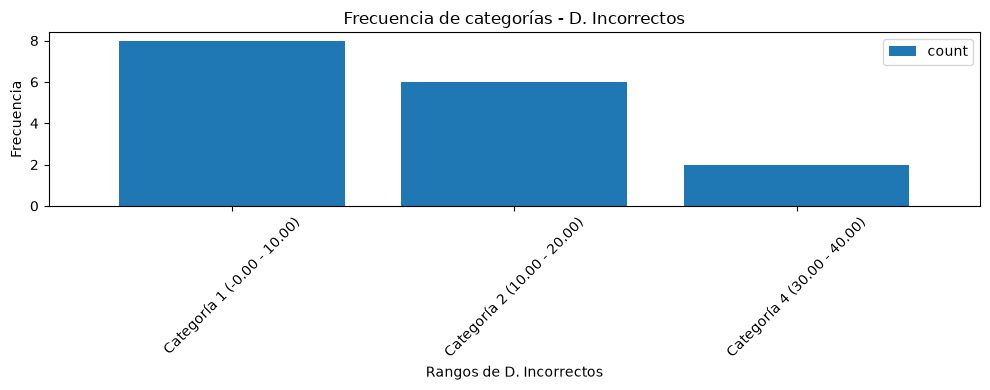

In [31]:
Tabla_DIncorrectos = categorizar_sturges(
    leads,
    "D. Incorrectos"
)

“Duplicados”

Variable: Duplicados
n = 18
Mínimo = 0.0
Máximo = 59.0
Rango = 59.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 9.833333333333334
Intervalos:
[-1.00000000e-03  9.83333333e+00  1.96666667e+01  2.95000000e+01
  3.93333333e+01  4.91666667e+01  5.90010000e+01]


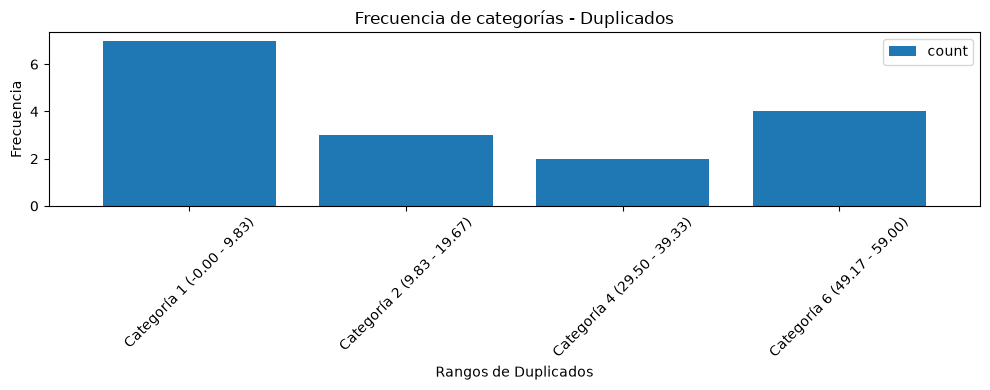

In [32]:
Tabla_Duplicados = categorizar_sturges(
    leads,
    "Duplicados"
)

“Efectivos”

Variable: Efectivos
n = 18
Mínimo = 128.0
Máximo = 1040.0
Rango = 912.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 152.0
Intervalos:
[ 127.999  280.     432.     584.     736.     888.    1040.001]


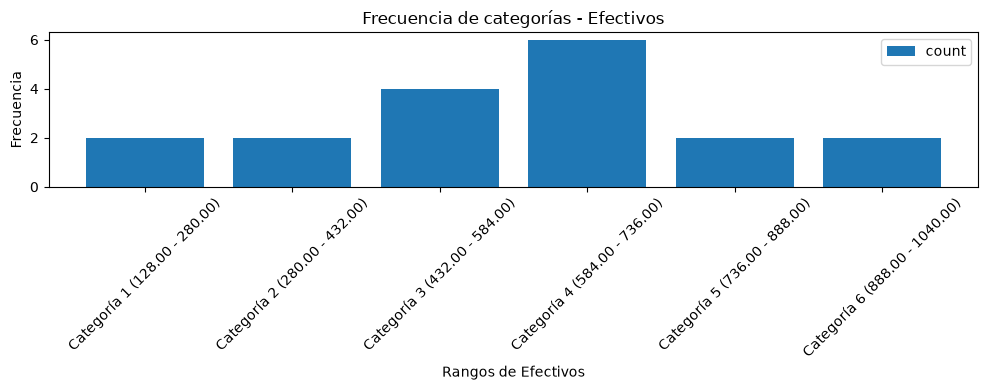

In [33]:
Tabla_Efectivos = categorizar_sturges(
    leads,
    "Efectivos"
)

“Abiertos”

Variable: Abiertos
n = 18
Mínimo = 1.0
Máximo = 823.0
Rango = 822.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 137.0
Intervalos:
[  0.999 138.    275.    412.    549.    686.    823.001]


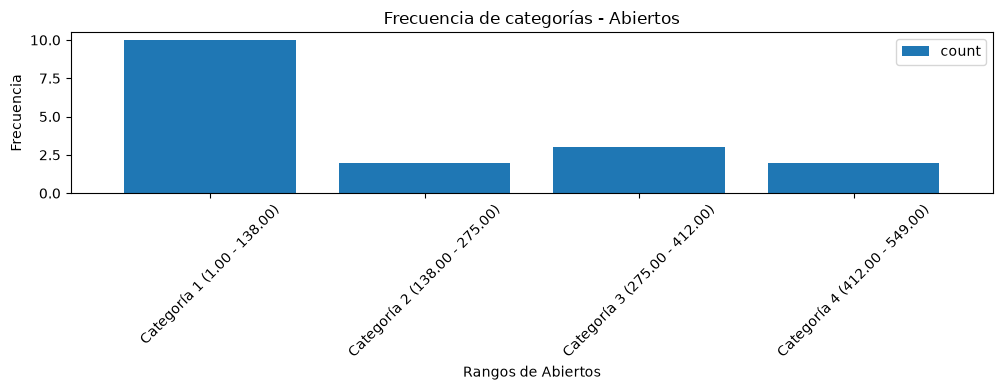

In [34]:
Tabla_Abiertos = categorizar_sturges(
    leads,
    "Abiertos"
)

“Ventas”

Variable: Ventas
n = 18
Mínimo = 6.0
Máximo = 41.0
Rango = 35.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 5.833333333333333
Intervalos:
[ 5.999      11.83333333 17.66666667 23.5        29.33333333 35.16666667
 41.001     ]


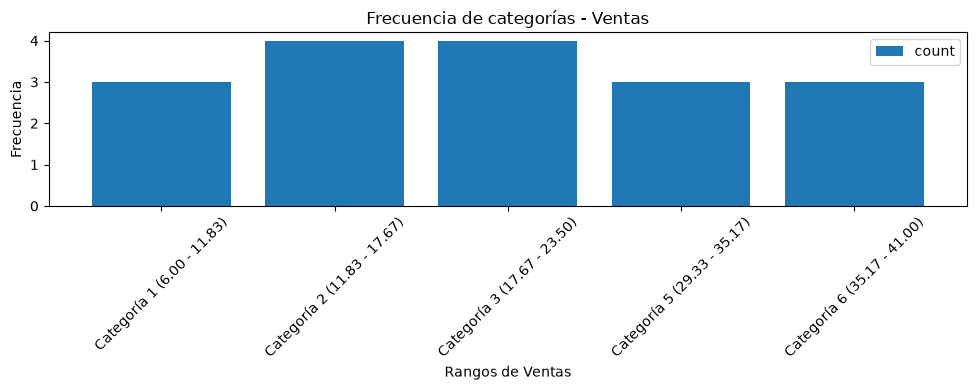

In [35]:
Tabla_Ventas = categorizar_sturges(
    leads,
    "Ventas"
)

“Conversion”

Variable: Conversion 
n = 18
Mínimo = 1.0
Máximo = 5.8
Rango = 4.8
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 0.7999999999999999
Intervalos:
[0.999 1.8   2.6   3.4   4.2   5.    5.801]


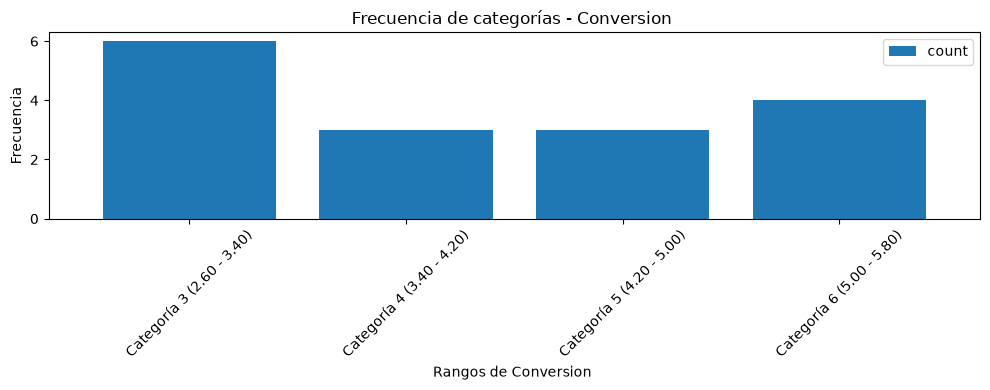

In [37]:
Tabla_Conversion = categorizar_sturges(
    leads,
    "Conversion "
)

“Efectividad de Leads”

Variable: Efectividad de Leads
n = 18
Mínimo = 39.0
Máximo = 83.0
Rango = 44.0
Número de intervalos según Sturges = 5.167504716942976
Número de intervalos utilizado = 6
Ancho del intervalo = 7.333333333333333
Intervalos:
[38.999      46.33333333 53.66666667 61.         68.33333333 75.66666667
 83.001     ]


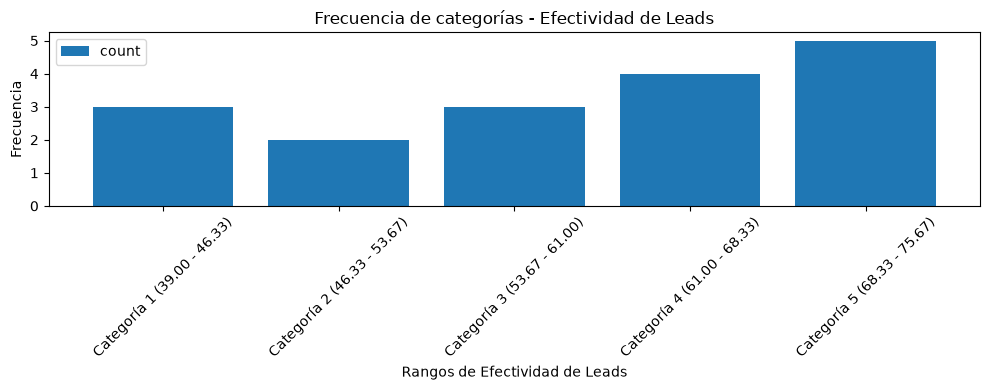

In [38]:
Tabla_Efectividad = categorizar_sturges(
    leads,
    "Efectividad de Leads"
)